In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Q1 - EDA

In [3]:
# Load a dataset

titanic = pd.DataFrame(sns.load_dataset('titanic'))
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Display stats

print(f'Shape: {titanic.shape}\n')

Shape: (891, 15)



In [5]:
print('Info:')
print(titanic.info())

Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None


In [6]:
print('Data Types:')
print(titanic.dtypes)

Data Types:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [7]:
print('Describe')
print(titanic.describe())

Describe
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200


In [8]:
print('Missing Values:')
print(titanic.isnull().sum())

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [9]:
print('Duplicates:')
print(titanic.duplicated().sum())

Duplicates:
107


In [10]:
# Clean the data

titanic = titanic.drop_duplicates()

titanic['deck'].isnull().sum() / len(titanic) * 100

np.float64(74.23469387755102)

In [11]:
# Summary Table

numeric_df = titanic.select_dtypes(include='number')

summary = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Mode': numeric_df.mode().iloc[0],
})

print('Summary Table:')
print(summary)

Summary Table:
               Mean  Median  Mode
survived   0.411990    0.00   0.0
pclass     2.243622    3.00   3.0
age       29.869351   28.25  24.0
sibsp      0.522959    0.00   0.0
parch      0.415816    0.00   0.0
fare      34.711740   15.90  13.0


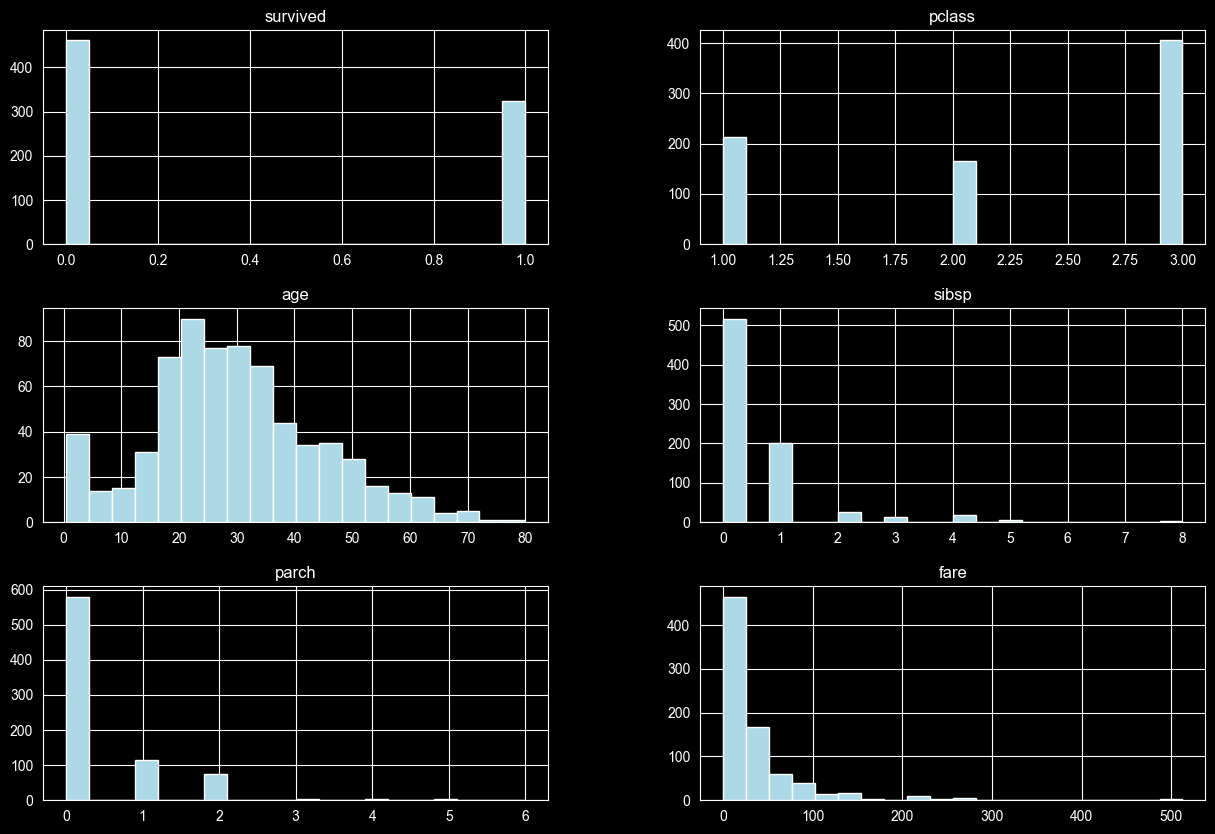

In [12]:
numeric_df.hist(bins=20, figsize=(15,10), color='lightblue')
plt.show()

#### Q2 - EDA using Univariate Analysis

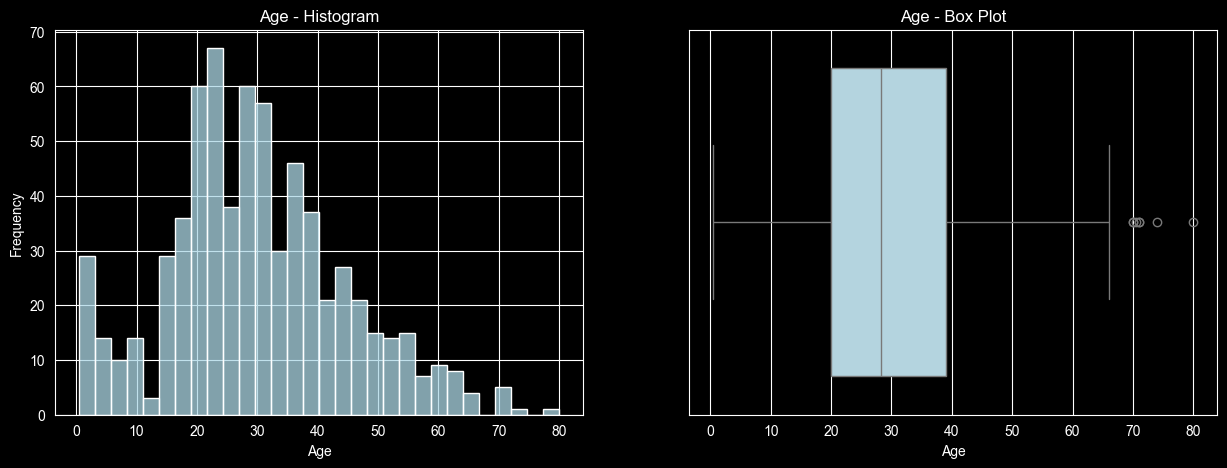

In [13]:
# Numeric col

fig, axes = plt.subplots(1,2,figsize=(15,5))

sns.histplot(data=titanic, x='age', bins=30, ax=axes[0], color='lightblue')
axes[0].set_title('Age - Histogram')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')


sns.boxplot(data=titanic, x='age', ax=axes[1], color='lightblue')
axes[1].set_title('Age - Box Plot')
axes[1].set_xlabel('Age')

plt.show()

In [17]:
# Skewness and kurtosis

print(f'Skewness: {titanic['age'].skew()}')
print(f'Kurtosis: {titanic['age'].kurt()}')

Skewness: 0.3674542095476674
Kurtosis: 0.09072738061837127


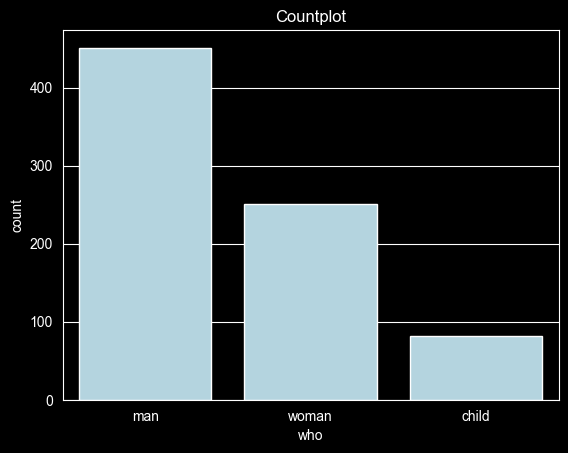

In [37]:
# Categorical Col

sns.countplot(x=titanic['who'], color='lightblue')
plt.title('Countplot')
plt.show()

#### Q3 - EDA using Bivariate Analysis

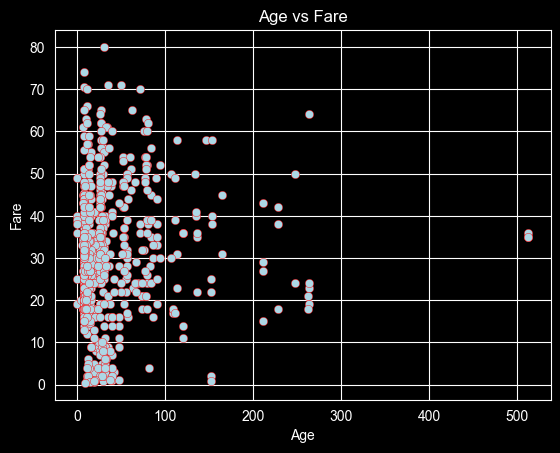

In [45]:
# Age & Fare

sns.scatterplot(data=titanic, x='fare', y='age', color='lightblue',edgecolor='red', linewidth=0.3)
plt.title('Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

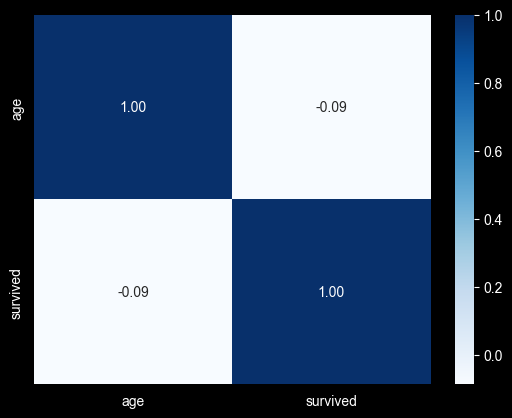

In [54]:
# Heatmap

cor = titanic[['age','survived']].corr()

sns.heatmap(cor, annot=True, cmap='Blues', fmt='.2f')
plt.show()

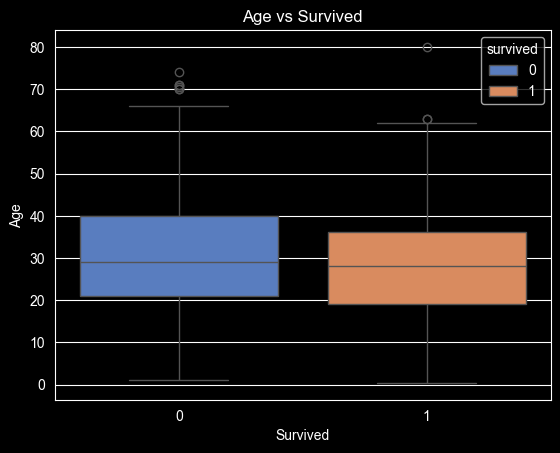

In [64]:
# Boxplot

sns.boxplot(data=titanic, x='survived',y='age', palette='muted', hue='survived')
plt.title('Age vs Survived')
plt.xlabel('Survived')
plt.ylabel('Age')
plt.show()




In [68]:
# Crosstab

pd.crosstab(titanic['sex'], titanic['survived'], margins=True,normalize=True)*100


survived,0,1,All
sex,,,
female,9.693878,27.678571,37.372449
male,49.107143,13.520408,62.627551
All,58.801020,41.198980,100.000000


#### Q4 - EDA using Multivariate Analysis